In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Step 1: Loading and Preprocessing Data...")
fraud_data = pd.read_csv('../data/raw/Fraud_Data.csv').drop_duplicates()
ip_data = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

# Format timestamps
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Optimized Geolocation Integration
fraud_data['ip_int'] = fraud_data['ip_address'].fillna(0).astype(np.int64)
ip_sorted = ip_data.sort_values(by='lower_bound_ip_address').reset_index(drop=True)
idx = np.searchsorted(ip_sorted['lower_bound_ip_address'].values, fraud_data['ip_int'].values) - 1
idx = np.clip(idx, 0, len(ip_sorted) - 1)
valid_mask = (fraud_data['ip_int'].values >= ip_sorted['lower_bound_ip_address'].values[idx]) & \
             (fraud_data['ip_int'].values <= ip_sorted['upper_bound_ip_address'].values[idx])
fraud_data['country'] = np.where(valid_mask, ip_sorted['country'].values[idx], 'Unknown')

# Feature Engineering
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
fraud_data['user_device_count'] = fraud_data.groupby('device_id')['user_id'].transform('count')
fraud_data['user_ip_count'] = fraud_data.groupby('ip_address')['user_id'].transform('count')

# Encode Categoricals and Drop IDs
categorical_cols = ['source', 'browser', 'sex', 'country']
encoded_df = pd.get_dummies(fraud_data, columns=categorical_cols, drop_first=True)
drop_identifiers = ['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'ip_int', 'class']

X = encoded_df.drop(columns=drop_identifiers)
y = encoded_df['class']

# Stratified Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
numerical_features = ['purchase_value', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_device_count', 'user_ip_count']
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print(f"Data ready! Training Matrix Size: {X_train.shape}")

Step 1: Loading and Preprocessing Data...
Data ready! Training Matrix Size: (120889, 195)


In [3]:
def evaluate_model_performance(model, X_tst, y_tst, name="Model"):
    preds = model.predict(X_tst)
    probs = model.predict_proba(X_tst)[:, 1]
    
    f1 = f1_score(y_tst, preds)
    precision_vals, recall_vals, _ = precision_recall_curve(y_tst, probs)
    auc_pr = auc(recall_vals, precision_vals)
    
    print(f"\n=================== {name} Evaluation ===================")
    print(classification_report(y_tst, preds))
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_tst, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
    ax[0].set_title(f'{name} Confusion Matrix')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')
    
    ax[1].plot(recall_vals, precision_vals, color='purple', label=f'AUC-PR = {auc_pr:.4f}')
    ax[1].set_title(f'{name} Precision-Recall Curve')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].legend(loc='lower left')
    plt.tight_layout()
    plt.show()
    
    return {"F1-Score": f1, "AUC-PR": auc_pr}
print("Evaluation helper function loaded successfully!")

Evaluation helper function loaded successfully!


Training Baseline Logistic Regression (with SMOTE)...


C:\Users\Rio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=================== Baseline Logistic Regression Evaluation ===================
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27393
           1       0.60      0.66      0.63      2830

    accuracy                           0.93     30223
   macro avg       0.78      0.81      0.79     30223
weighted avg       0.93      0.93      0.93     30223



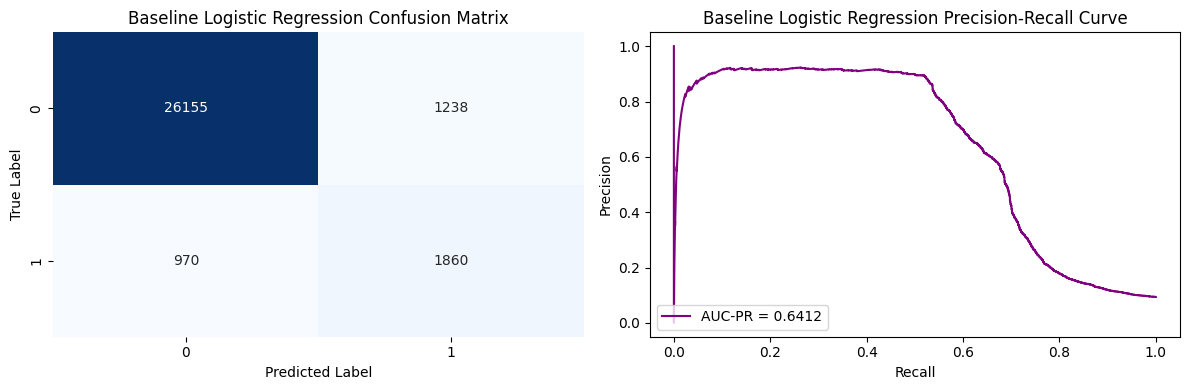

In [4]:
print("Training Baseline Logistic Regression (with SMOTE)...")
lr_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=500, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_metrics = evaluate_model_performance(lr_pipeline, X_test, y_test, name="Baseline Logistic Regression")

Training Tuned Random Forest Ensemble (with SMOTE)...

=================== Tuned Random Forest Ensemble Evaluation ===================
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     27393
           1       0.54      0.69      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.75      0.82      0.78     30223
weighted avg       0.93      0.92      0.92     30223



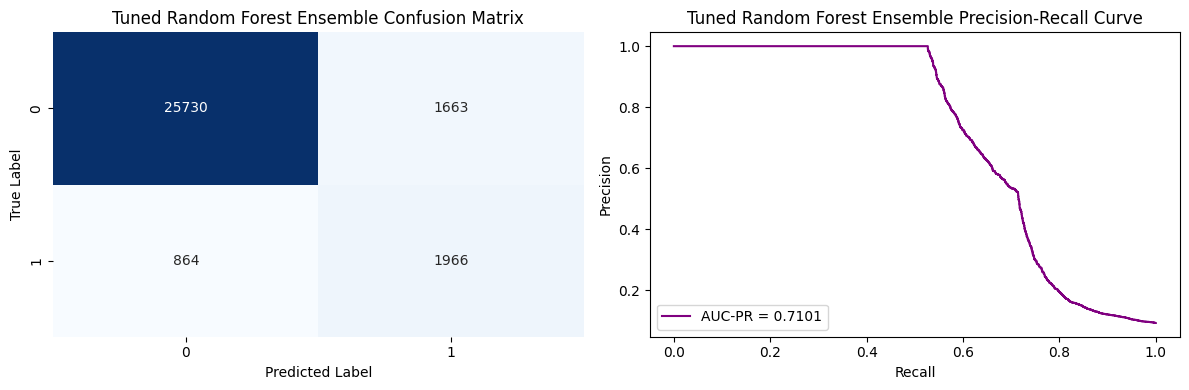


Running 5-Fold Stratified Cross-Validation to verify reliability...

--- Cross Validation Final Averages ---
Mean CV F1-Score: 0.6234 +/- 0.0079
Mean CV AUC-PR: 0.7153 +/- 0.0044


In [5]:
print("Training Tuned Random Forest Ensemble (with SMOTE)...")
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
rf_metrics = evaluate_model_performance(rf_pipeline, X_test, y_test, name="Tuned Random Forest Ensemble")

print("\nRunning 5-Fold Stratified Cross-Validation to verify reliability...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=cv_strategy, scoring=['f1', 'average_precision'], n_jobs=-1)

print("\n--- Cross Validation Final Averages ---")
print(f"Mean CV F1-Score: {np.mean(cv_results['test_f1']):.4f} +/- {np.std(cv_results['test_f1']):.4f}")
print(f"Mean CV AUC-PR: {np.mean(cv_results['test_average_precision']):.4f} +/- {np.std(cv_results['test_average_precision']):.4f}")